# Open, Plot a grd-file (Golden Surfer), and create contours

This example shows how to read a grd.-file.

## The grd.-file format

Golden Software Surfer ASCII Grid File Format (*.grd) 

I have this from 
[ftp://mapserver.dk/Website/GeoScene3D/Help/GeoScene3D.html?SurferGridFile](ftp://mapserver.dk/Website/GeoScene3D/Help/GeoScene3D.html?SurferGridFile)

    DSAA                                                  
    257 257
    5.67000000000000E+0005  5.77000000000000E+0005
    6.21000000000000E+0006  6.22000000000000E+0006
    2.03093853524560E+0002  2.99665271953120E+0001
    -90.5562486071858 -91.9770019939907 -93.4370976218987 -94.9176582413338 -96.8107561059735 -99.2457412347054 -102.100555111382 -105.05927200815 -107.450170173252 -108.397479844771 -108.006809781027 -106.952517601354 -105.649614366893 -104.213695019001 -102.692112629755 -101.114516990419 -99.5158982996779 -98.0913386982125 -97.2416961687762 -96.867635747979 -96.6288440424081 -96.4139655410412 -96.2387366687169 -96.1506385669487 -96.1889866969817 -96.3482126058032 -96.5828465379148 -96.8358291868982 -97.0430392786954 -97.1594814373822 -97.1602791675428 -97.0169815683541 -96.7126902739287 -96.2489776000008 -95.6594416328783 -94.9880962912902 -94.261664220667 -93.4897016947069 -92.7279351980489 -91.9532740429494 -91.1767254779275 -90.4266084443076 -89.731553749896 -89.120125489303 -88.683328917954 -88.356633504079 -88.167904067882 -88.023035728318 -87.838911878194 -87.552725344546 -87.266720734973.......

Line 1: File type indicator

Line 2: Number of columns and rows

Line 3: Min and max X

Line 4: Min and max Y

Line 5: Min and max Z (point elevation)

Line 6: First row of nodes in the grid

Line 7: Second row of nodes

## Loading the Data

Loads the grid definition (min, max, n for x,y-axis and values) in variables and the data into a numpy array

In [65]:
filename = "head.grd"
grdfile = open(filename)

# Line 1: File type indicator
line = grdfile.readline().strip()
assert line == "DSAA", "missing DSSA keyword in first line - not a Surfer grd?"

# Line 2: Number of columns and rows
line = grdfile.readline().strip()
ncol, nrow = line.split()
ncol, nrow = int(ncol), int(nrow)

# Line 3: Min and max X
line = grdfile.readline().strip()
xmin, xmax = line.split()
xmin, xmax = float(xmin), float(xmax)

# Line 4: Min and max Y
line = grdfile.readline().strip()
ymin, ymax = line.split()
ymin, ymax = float(ymin), float(ymax)

# Line 5: Min and max Z (point elevation)
line = grdfile.readline().strip()
zmin, zmax = line.split()
zmin, zmax = float(zmin), float(zmax)

# nrow data lines
rows = []
line = grdfile.readline().strip()
while line != "":
    words = line.split()
    rows.append(words)
    line = grdfile.readline().strip()

# convert to numpy array
import numpy as np
z = np.array(rows, np.float)
del(rows)

## Plot the matrix

Plotting the bulk data alone is easy, it will appear upside down and with no spation context ...

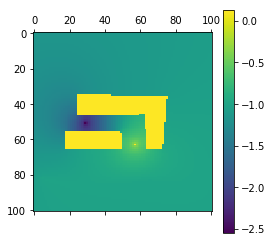

In [66]:
% matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.matshow(z)
plt.clim(vmin=zmin, vmax=zmax)
plt.colorbar()
plt.show()

... so its better to use use the meshgrid object from matplotlib for plotting. That way, contouring and fringes can be plotted as well.

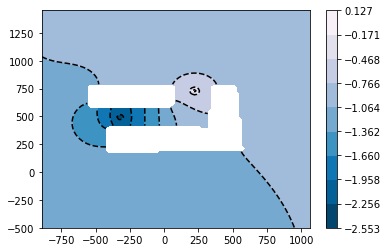

In [67]:
x = np.linspace(xmin, xmax, ncol)
y = np.linspace(ymin, ymax, nrow)
X, Y = np.meshgrid(x, y)

from matplotlib import ticker, cm
from numpy import ma

z = ma.masked_where(z > zmax , z)  # avoid plots at NAN-areas

fig, ax = plt.subplots()
levs = np.linspace(zmin, zmax, 10)
cs = ax.contourf(X, Y, z, levs, cmap=cm.PuBu_r)
ct = ax.contour(X, Y, z, levs, colors='k', corner_mask=True)
plt.colorbar(cs)
plt.show()

Checkout the notebook to handle shape files on exporting the cs / ct objects above for further GIS processing.